### Dataset Description

The given cell generates:

* **Feature matrix ( X )** of shape ( (n, d) )

  * ( n ): number of samples (data points)
  * ( d ): number of features (input variables)

* **Target vector ( y )** of shape ( (n,) )

  * Contains the output/label corresponding to each sample

---

### Important Instructions

* This dataset will be used throughout the assignment
* **Do not modify the cell**, as it ensures consistency in results


In [24]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y = True)

# set the random seed value to 0
np.random.seed(0)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

### Problem 1
How many samples are there in the dataset?

In [26]:
print(X.shape[0])

442


### Problem 2
How many features are there in the dataset?

In [27]:
print(X.shape[1])

10


### Problem 3
Write a function `shuffle_data(X, y)` that returns the shuffled `X` and `y`.

Note that it should shuffle the data pairs `(xi, yi)`.

What will be the mean of the first 5 values in `y`?

In [28]:
def Shuffled_Data(X , Y):
    idx = np.random.permutation(len(Y))
    return X[idx] , Y[idx]
x_shuffled , y_shuffled = Shuffled_Data(X , y)
print(np.mean(y_shuffled[:5]))

180.4


### Problem 4
Write a function `train_test_split(X, y, test_size)` that divides the data `(X, y)` into `Xtrain`, `Xtest`, `ytrain`, `ytest` respectively as per `test_size`, which should be a value between 0 and 1.

That is, if `test_size = t`, then `int(t * n)` data points should go to test and the remaining data points should go to train.

`Xtrain`, `Xtest`, `ytrain`, `ytest` should be returned by the function.

Set the `test_size` to be `0.25` and output the sum of all `y` values settling in `ytest`.

In [29]:
def train_test_split(X, y, test_size):
    n = len(y)
    n_test = int(test_size * n)     # 110
    n_train = n - n_test            # 332

    Xtest  = X[:n_test]             # pehle 110 rows
    ytest  = y[:n_test]             # pehle 110 values

    Xtrain = X[n_test:]             # baaki 332 rows
    ytrain = y[n_test:]             # baaki 332 values

    return Xtrain, Xtest, ytrain, ytest


# Pehle shuffle karo (Problem 3 se)
X_shuffled, y_shuffled = Shuffled_Data(X, y)

# Ab split karo
Xtrain, Xtest, ytrain, ytest = train_test_split(X_shuffled, y_shuffled, test_size=0.25)

# Sum of ytest
print(np.sum(ytest))

17178.0


### Problem 5
What are the shapes of `Xtrain`, `Xtest`, `ytrain`, `ytest` respectively?

In [30]:
print(Xtrain.shape , Xtest.shape , ytrain.shape , ytest.shape)

(332, 10) (110, 10) (332,) (110,)


### Problem 6
Add a dummy feature, i.e., a column containing all 1's (as the first column) in `Xtrain` and `Xtest`.

Take the transpose of both `Xtrain` and `Xtest`.

What are the shapes of `Xtrain` and `Xtest`?

In [ ]:
one_train = np.ones((Xtrain.shape[0], 1))
one_test  = np.ones((Xtest.shape[0], 1))

Xtrain_withDummy = np.hstack([one_train, Xtrain]) 
Xtest_withDummy  = np.hstack([one_test,  Xtest])

Xtrain = Xtrain_withDummy.T 
Xtest  = Xtest_withDummy.T   

print(Xtrain.shape, Xtest.shape)

(11, 332) (11, 110)


### Problem 7
Write a function `compute_weights(X, y)` that uses the closed form formula of linear regression and returns a weight vector.

Call this function by passing `Xtrain` and `ytrain`. As the dummy feature was added as the first column, the first value in the weight vector will be the intercept.

What is its value (rounded to one decimal place)?

In [49]:
def compute_weights(X, y):
    # w = (X @ X.T)^(-1) @ X @ y
    XXT     = X @ X.T                  # (11,332) @ (332,11) = (11,11)
    XXT_inv = np.linalg.inv(XXT)       # inverse → (11,11)
    w       = XXT_inv @ X @ y          # (11,11) @ (11,332) @ (332,) = (11,)
    return w

W = compute_weights(Xtrain, ytrain )
print(round(W[0] , 1))
print(W.shape,Xtest.shape , ytest.shape)


151.7
(11,) (11, 110) (110,)


### Problem 8
Write a function `MSE(X, y, w)` that returns the mean squared error for the given `X`, `y` as per `w` values.

Using this function, compute the train error and test error.

Note: Here `y` is the true `y` for `X`.

Compute both train and test error.

What is the value of test error?

In [54]:
def MSE(X, y, w):
    y_pred = w.T @ X        # predicted values → shape: (n,)
    error  = y - y_pred     # difference
    mse    = np.mean(error ** 2)  # square karke average lo
    return mse

# Train error
train_error = MSE(Xtrain, ytrain, W)
print("Train MSE:", train_error)

# Test error
test_error = MSE(Xtest, ytest, W)
print("Test MSE:", test_error)

Train MSE: 2831.729411989177
Test MSE: 2997.1035258796805


### Problem 9
Write a function `compute_weights_ridge(X, y)` that uses the closed form formula of Ridge regression and returns a weight vector.

Call this function by passing `X_train`, `y_train` and `0.3` as the value of regularization strength.

Find the sum of values in the weight vector obtained. How much reduction in total sum of weights is achieved with respect to the weight vector obtained from “plain” linear regression (without regularization) computed earlier.

In [52]:
def compute_weights_ridge(X, y, lamda):
    n = X.shape[0]           # 11 (features + bias)
    I = np.eye(n)            # Identity matrix (11×11)

    XXT     = X @ X.T                        # (11,11)
    XXT_reg = XXT + lamda * I                # (11,11) + λI
    w_ridge = np.linalg.inv(XXT_reg) @ X @ y # (11,)
    return w_ridge

# Call karo
w_ridge = compute_weights_ridge(Xtrain, ytrain, lamda=0.3)

# Sum of weights
sum_ridge  = np.sum(w_ridge)
sum_linear = np.sum(w)           # Problem 7 se w

print("Sum (Ridge):",  sum_ridge)
print("Sum (Linear):", sum_linear)

# Reduction
reduction = sum_linear - sum_ridge
print("Reduction:", reduction)

Sum (Ridge): 1005.0193562884087
Sum (Linear): 1683.6227036300234
Reduction: 678.6033473416146


### Problem 10
Compute the train error and test error.

What is their absolute difference?

In [53]:
# Train aur test error with ridge weights
train_error_ridge = MSE(Xtrain, ytrain, w_ridge)
test_error_ridge  = MSE(Xtest, ytest, w_ridge)

print("Train Error (Ridge):", train_error_ridge)
print("Test Error (Ridge):",  test_error_ridge)

# Absolute difference
diff = abs(train_error_ridge - test_error_ridge)
print("Absolute Difference:", round(diff, 1))

Train Error (Ridge): 2984.3059851079765
Test Error (Ridge): 3047.3863807567013
Absolute Difference: 63.1


### Problem 11
Use 10 different values between 0 and 5 as the regularization strength and keep a record of the weight vectors obtained for each.

Further, calculate the sum of weights for each weight vector.

Plot these sums of weights (on y-axis) with respect to the regularization strength (on x-axis) and observe the reduction in (sum of) weights.

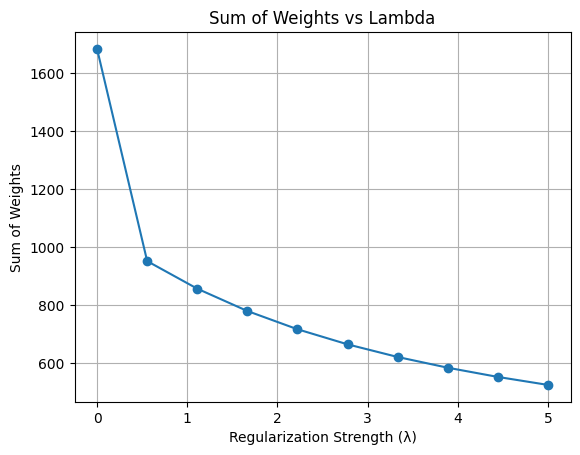

In [55]:
lambdas = np.linspace(0, 5, 10)
sums = []

for lam in lambdas:
    w_r = compute_weights_ridge(Xtrain, ytrain, lamda=lam)
    sums.append(np.sum(w_r))

plt.plot(lambdas, sums, marker='o')
plt.xlabel('Regularization Strength (λ)')
plt.ylabel('Sum of Weights')
plt.title('Sum of Weights vs Lambda')
plt.grid(True)
plt.show()